# 03 · Simulator

In alternate shot, who hits which shot depends on the hole number and the stroke count. So we simulate shot by shot, then turn holes into matches exactly.

Three layers: replay real shots adjusted for skill; simulate many copies of a hole; compute match and fixture odds exactly.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.pipeline import build
from src.simulator import (ShotModel, simulate_hole, hole_pmfs, hole_outcomes, match_play, fixture,
                           league_course, pair_vs_pair, monte_carlo_match, LIE_IDX, TEE)
from src.strokes_gained import CATEGORIES
from src.data_prep import HOLE_KEY
from src.viz import set_style, PALETTE, NEUTRAL, INK_2

set_style()
pd.set_option("display.width", 200)

P = build()                      # cached output of notebook 02
shots, ratings = P["shots"], P["ratings"]
model = ShotModel.build(shots, ratings)
print(f"{len(model.pools)} shot situations with their own pool of real outcomes")

483 shot situations with their own pool of real outcomes


## Replaying real shots

For each lie and distance we keep thousands of real shots. To simulate a shot we replay one of them. A better player gets the good outcomes a little more often (exponential tilting), just enough to match her rating. She still hits the occasional bad shot.

In [2]:
model.strokes_per_round.round(1).rename("field strokes per round").to_frame().T

category,OTT,APP,ARG,PUTT
field strokes per round,13.9,17.8,9.7,29.0


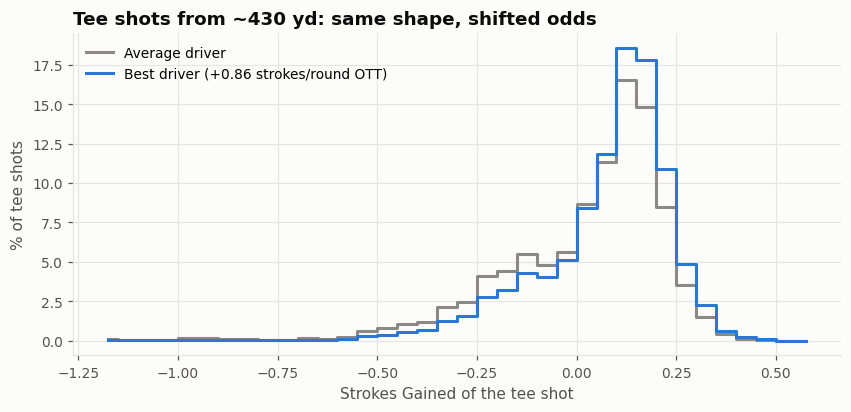

,average,best driver
mean SG per drive,0.012,0.074
penalty rate,0.014,0.002
fairway rate,0.568,0.654


In [3]:
best_driver = ratings.OTT.idxmax()
pool_id = model.state_pool(np.array([TEE]), np.array([430.0]))[0]
pool = model.pools[pool_id]
cdf_avg = model._cdf(pool_id, 0.0)
cdf_top = model._cdf(pool_id, model.skill(best_driver, CATEGORIES.index("OTT")))
w_avg = np.diff(np.r_[0, cdf_avg]); w_top = np.diff(np.r_[0, cdf_top])

bins = np.linspace(-1.2, 0.6, 37)
h_avg, _ = np.histogram(pool["sg"], bins, weights=w_avg)
h_top, _ = np.histogram(pool["sg"], bins, weights=w_top)
mid = (bins[:-1] + bins[1:]) / 2
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.step(mid, h_avg * 100, where="mid", color=NEUTRAL, label="Average driver")
ax.step(mid, h_top * 100, where="mid", color=PALETTE[0], label=f"Best driver (+{ratings.OTT.max():.2f} strokes/round OTT)")
ax.set(title="Tee shots from ~430 yd: same shape, shifted odds", xlabel="Strokes Gained of the tee shot", ylabel="% of tee shots")
ax.legend(loc="upper left")
plt.show()

summary = pd.DataFrame({
    "average": [w_avg @ pool["sg"], w_avg @ (pool["pen"] > 0), w_avg @ (pool["next_lie"] == LIE_IDX["LIE_4"])],
    "best driver": [w_top @ pool["sg"], w_top @ (pool["pen"] > 0), w_top @ (pool["next_lie"] == LIE_IDX["LIE_4"])],
}, index=["mean SG per drive", "penalty rate", "fairway rate"])
summary.round(3)

The best driver gains about 0.06 strokes per drive, finds more fairways and rarely takes a penalty. 

## simulation vs real golf?

We play an average player on every real hole, using only its length and par.

Mean error +0.003 strokes per hole; correlation 0.974


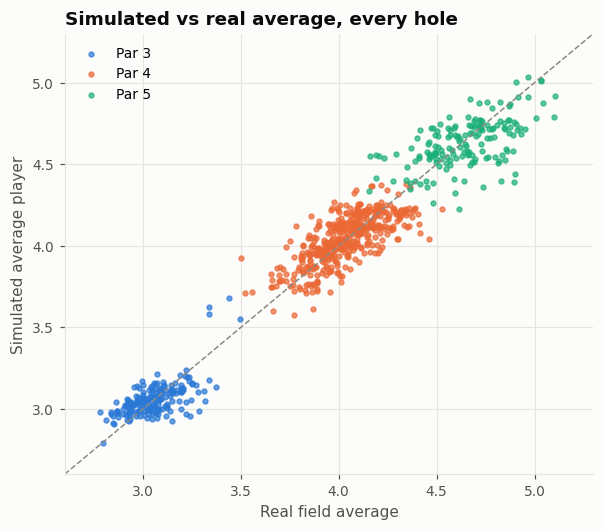

In [4]:
ch = P["course_holes"]
hole = shots[~shots.low_quality_event].drop_duplicates(HOLE_KEY)
act = hole.groupby(["event_id", "course_no", "hole_no"]).agg(real=("hole_score", "mean"), par=("par", "first"), n=("hole_score", "size"))
act = act.join(ch.set_index(["event_id", "course_no", "hole_no"]).hole_yd)
rng = np.random.default_rng(0)
labels = ["eagle or better", "birdie", "level par", "bogey", "double+"]
sim_mean, sim_types = [], []
for row in act.itertuples():
    s = simulate_hole(model, (None, None), row.hole_yd, int(row.par), 800, rng)
    sim_mean.append(s.mean())
    sim_types.append(np.bincount(np.clip(s - int(row.par) + 2, 0, 4), minlength=5) / len(s))
act["sim"] = sim_mean
print(f"Mean error {(act.sim - act.real).mean():+.3f} strokes per hole; correlation {act.sim.corr(act.real):.3f}")

fig, ax = plt.subplots(figsize=(6.2, 5.2))
for p, col in zip([3, 4, 5], PALETTE):
    d = act[act.par == p]
    ax.scatter(d.real, d.sim, s=10, alpha=0.7, color=col, label=f"Par {p}")
lim = [2.6, 5.3]
ax.plot(lim, lim, color=NEUTRAL, lw=1, ls="--")
ax.set(xlim=lim, ylim=lim, title="Simulated vs real average, every hole", xlabel="Real field average", ylabel="Simulated average player")
ax.legend(loc="upper left")
plt.show()

In [5]:
real_types = hole.assign(k=np.clip(hole.hole_score - hole.par + 2, 0, 4).astype(int)).groupby("par").k.value_counts(normalize=True).unstack().fillna(0)
real_types.columns = labels
st = pd.DataFrame(sim_types, index=act.index, columns=labels).assign(par=act.par.values, w=act.n.values)
sim_types_par = st[labels].mul(st.w, axis=0).groupby(st.par).sum().div(st.groupby("par").w.sum(), axis=0)
by_par = pd.concat({"real": act.groupby("par").real.mean(), "simulated": act.groupby("par").sim.mean()}, axis=1)
display(by_par.round(3))
pd.concat({"real": real_types, "simulated": sim_types_par}, axis=1).round(3)

,real,simulated
par,,
3,3.054,3.061
4,4.032,4.041
5,4.648,4.631


real                                       simulated                                
    eagle or better birdie level par  bogey double+ eagle or better birdie level par  bogey double+
par                                                                                                
3             0.000  0.134     0.698  0.152   0.016           0.000  0.138     0.683  0.161   0.018
4             0.002  0.169     0.647  0.160   0.023           0.002  0.172     0.635  0.166   0.025
5             0.028  0.410     0.466  0.081   0.015           0.030  0.420     0.454  0.082   0.014

Hole averages match (r ≈ 0.97, no bias), and so do the birdie, par and bogey rates. 

Average player on the league course: 71.43 strokes, round-to-round SD 2.83 (observed: 2.80)


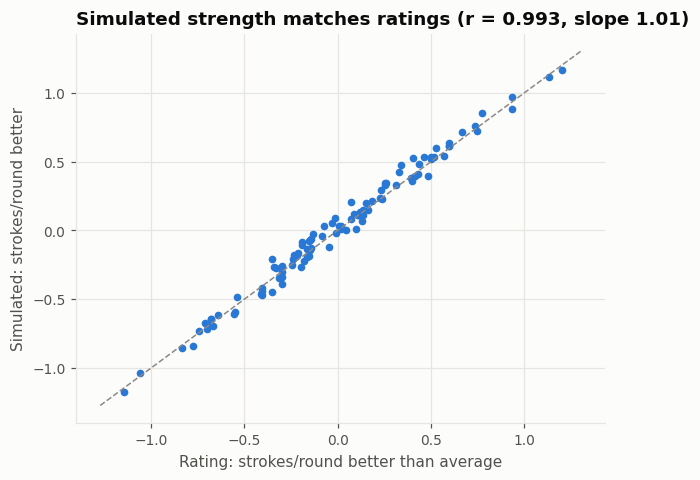

In [6]:
course = league_course(ch, shots)
avg = hole_pmfs(model, course, (None, None), n=20000, seed=1)
k = np.arange(avg.shape[1])
mean_avg = (avg * k).sum()
sd_avg = np.sqrt(((avg * k ** 2).sum(1) - (avg * k).sum(1) ** 2).sum())
print(f"Average player on the league course: {mean_avg:.2f} strokes, round-to-round SD {sd_avg:.2f} (observed: {P['fits']['sg_total'].sigma_e:.2f})")

sim_edge = {}
for i, p in enumerate(ratings.index):
    pm = hole_pmfs(model, course, (p, p), n=3000, seed=100 + i)
    sim_edge[p] = mean_avg - (pm * k).sum()
chk = pd.DataFrame({"simulated edge": pd.Series(sim_edge), "rating (sum of game areas)": ratings[CATEGORIES].sum(axis=1)})
slope = np.polyfit(chk.iloc[:, 1], chk.iloc[:, 0], 1)[0]

fig, ax = plt.subplots(figsize=(6.2, 4.6))
ax.scatter(chk.iloc[:, 1], chk.iloc[:, 0], s=16, color=PALETTE[0])
lim = [chk.min().min() - 0.1, chk.max().max() + 0.1]
ax.plot(lim, lim, color=NEUTRAL, lw=1, ls="--")
ax.set(title=f"Simulated strength matches ratings (r = {chk.corr().iloc[0, 1]:.3f}, slope {slope:.2f})",
       xlabel="Rating: strokes/round better than average", ylabel="Simulated: strokes/round better")
plt.show()

The round-to-round spread comes out at ±2.83 against ±2.80 in real data, without any tuning. Each player's simulated strength also matches her rating. Next: the course we play on.

## The league course

The brief gives no course, so we use a typical par-72 course from the data.

In [7]:
course.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
hole_no,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0
par,4.0,4.0,5.0,3.0,4.0,4.0,3.0,5.0,4.0,4.0,3.0,4.0,4.0,5.0,3.0,4.0,4.0,5.0
yd,373.0,416.0,576.0,163.0,355.0,443.0,161.0,607.0,479.0,455.0,189.0,486.0,353.0,582.0,214.0,439.0,453.0,576.0


In [8]:
print("Par on odd holes:", course[course.hole_no % 2 == 1].par.tolist(), "· total", course[course.hole_no % 2 == 1].par.sum())
print("Par on even holes:", course[course.hole_no % 2 == 0].par.tolist(), "· total", course[course.hole_no % 2 == 0].par.sum())
print("Tee-shot yardage, odd vs even:", course[course.hole_no % 2 == 1].yd.sum(), course[course.hole_no % 2 == 0].yd.sum())

Par on odd holes: [4, 5, 4, 3, 4, 3, 4, 3, 4] · total 34
Par on even holes: [4, 3, 4, 5, 4, 4, 5, 4, 5] · total 38
Tee-shot yardage, odd vs even: 3153.0 4167.0


Most par 3s fall on odd holes, most par 5s on even holes. That decides which shots each partner hits.

## Alternate shot on one hole

The odd-hole player tees off on odd holes, her partner on even holes, then they alternate. Penalties do not change the order. We try the best driver with the best putter, both ways round.

In [9]:
best_putter = ratings.drop(best_driver).PUTT.idxmax()
duo = ratings.loc[[best_driver, best_putter], ["seed", "total"] + CATEGORIES].round(2)
duo.index = ["best driver", "best putter"]
display(duo)

res = {}
for name, pair in [("driver tees odd holes", (best_driver, best_putter)), ("driver tees even holes", (best_putter, best_driver))]:
    pm = hole_pmfs(model, course, pair, n=20000, seed=7)   # same seed = common random numbers
    res[name] = (pm * np.arange(pm.shape[1])).sum(1)
cmp = pd.DataFrame(res, index=course.hole_no).assign(par=course.par.values)
tot = cmp[list(res)].sum()
print("Expected pair score:", tot.round(2).to_dict(), f"· difference {abs(tot.iloc[0] - tot.iloc[1]):.2f} strokes per round")

,seed,total,OTT,APP,ARG,PUTT
best driver,2,1.28,0.86,0.13,0.12,0.10
best putter,42,0.87,-0.27,0.23,0.15,0.41


Expected pair score: {'driver tees odd holes': 70.65, 'driver tees even holes': 70.5} · difference 0.16 strokes per round


The driver should take the even holes, where the drives are. It is worth about 0.15 strokes per round. Next: turn holes into match results.

## Match play, computed exactly

Holes are independent, so the running score moves up, down or stays level each hole. We track every possible score hole by hole and stop when the match is decided. A brute-force check agrees.

In [10]:
top2 = ratings.sort_values("total", ascending=False).index[:2]
pa = hole_pmfs(model, course, (top2[0], top2[1]), n=4000, seed=11)
pb = hole_pmfs(model, course, (None, None), n=4000, seed=12)
outc = hole_outcomes(pa, pb)
exact = match_play(outc)
mc = monte_carlo_match(outc)
pd.DataFrame({"exact (DP)": [exact["A"], exact["halved"], exact["B"]], "Monte Carlo 200k": mc},
             index=["top pair wins", "halved", "average pair wins"]).round(4)

,exact (DP),Monte Carlo 200k
top pair wins,0.5515,0.5536
halved,0.1230,0.1226
average pair wins,0.3254,0.3238


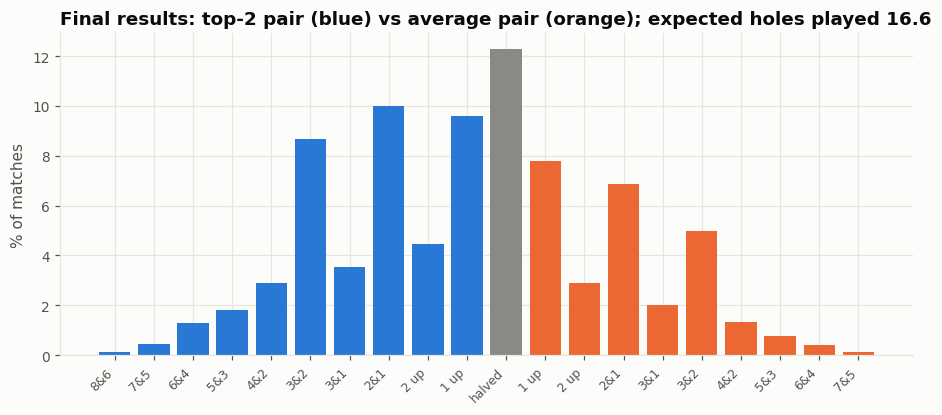

In [11]:
fin = pd.Series(exact["finals"]).sort_values(ascending=False)
order = [f"A {m}&{r}" for m, r in [(10, 8), (9, 7), (8, 6), (7, 5), (6, 4), (5, 3), (4, 2), (3, 2), (3, 1), (2, 1)]] + ["A 2 up", "A 1 up", "halved", "B 1 up", "B 2 up"] + \
        [f"B {m}&{r}" for m, r in [(2, 1), (3, 1), (3, 2), (4, 2), (5, 3), (6, 4), (7, 5), (8, 6)]]
fin = fin.reindex([o for o in order if o in fin.index])
fin = fin[fin > 0.0005]
fig, ax = plt.subplots(figsize=(10, 3.8))
colors = [PALETTE[0] if k.startswith("A") else (NEUTRAL if k == "halved" else PALETTE[1]) for k in fin.index]
ax.bar(range(len(fin)), fin.values * 100, color=colors, width=0.8)
ax.set_xticks(range(len(fin))); ax.set_xticklabels([k.replace("A ", "").replace("B ", "") for k in fin.index], rotation=45, ha="right", fontsize=8)
ax.set(title=f"Final results: top-2 pair (blue) vs average pair (orange); expected holes played {exact['holes_played']:.1f}",
       ylabel="% of matches")
plt.show()

## How much does skill buy?

Pairs better than average by a fixed amount play an average pair.

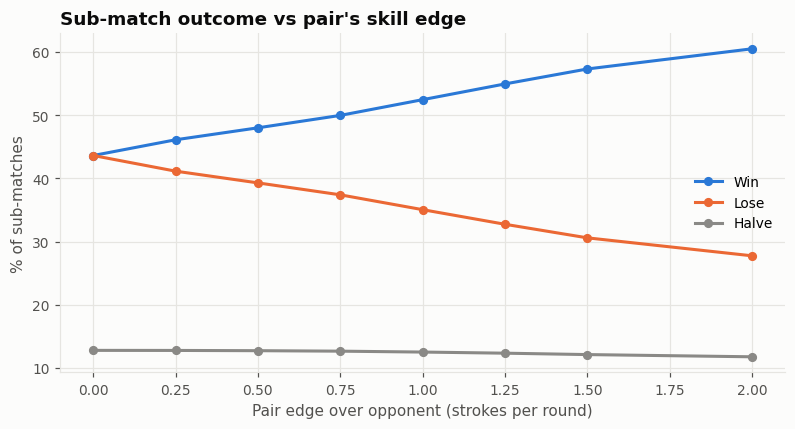

,win,halve,lose,points
edge,,,,
0.00,0.436,0.128,0.436,0.500
0.25,0.461,0.127,0.411,0.525
0.50,0.480,0.127,0.393,0.544
0.75,0.500,0.126,0.374,0.563
1.00,0.525,0.125,0.350,0.587
1.25,0.550,0.123,0.327,0.611
1.50,0.573,0.121,0.306,0.634
2.00,0.605,0.117,0.277,0.664


In [12]:
share = pd.Series({c: P["fits"][f"sg_{c}"].sigma_s for c in CATEGORIES}); share /= share.sum()
xs = [0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
pb = hole_pmfs(model, course, (None, None), n=12000, seed=21)
curve = []
for x in xs:
    name = f"+{x}"
    model.add_player(name, (share * x).to_dict())
    pa = hole_pmfs(model, course, (name, name), n=12000, seed=21)   # common random numbers
    r = match_play(hole_outcomes(pa, pb))
    curve.append({"edge": x, "win": r["A"], "halve": r["halved"], "lose": r["B"], "points": r["A"] + r["halved"] / 2})
curve = pd.DataFrame(curve).set_index("edge")

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(curve.index, curve.win * 100, color=PALETTE[0], marker="o", ms=5, label="Win")
ax.plot(curve.index, curve.lose * 100, color=PALETTE[1], marker="o", ms=5, label="Lose")
ax.plot(curve.index, curve.halve * 100, color=NEUTRAL, marker="o", ms=5, label="Halve")
ax.set(title="Sub-match outcome vs pair's skill edge", xlabel="Pair edge over opponent (strokes per round)", ylabel="% of sub-matches")
ax.legend(loc="center right")
plt.show()
curve.round(3)

A pair one stroke per round better still loses about a third of its matches. 

## Fixtures

Five independent sub-matches. Stopping at 3 points changes when play ends, not who wins. As a demo, ten teams draft by seed only.

In [13]:
def snake_by_seed(n_teams=10, rounds=10):
    order = ratings.sort_values("seed").index.tolist()
    teams = {t: [] for t in range(1, n_teams + 1)}
    for r in range(rounds):
        seq = range(1, n_teams + 1) if r % 2 == 0 else range(n_teams, 0, -1)
        for t in seq:
            teams[t].append(order.pop(0))
    return teams

teams = snake_by_seed()
def lineup(team):  # naive: pairs in seed order
    return [(team[2 * i], team[2 * i + 1]) for i in range(5)]

def play_fixture(team_a, team_b, n=4000, seed=0):
    ms = [pair_vs_pair(model, course, a, b, n=n, seed=seed + 31 * i) for i, (a, b) in enumerate(zip(lineup(team_a), lineup(team_b)))]
    return fixture(ms), ms

for t in [1, 10]:
    print(f"Team {t}: seeds {sorted(ratings.loc[teams[t], 'seed'].tolist())} · mean rating {ratings.loc[teams[t], 'total'].mean():+.2f}")
res, ms = play_fixture(teams[1], teams[10])
pd.DataFrame([{"pair": i + 1, "Team 1 wins": m["A"], "halved": m["halved"], "Team 10 wins": m["B"]} for i, m in enumerate(ms)]).set_index("pair").round(3)

Team 1: seeds [1, 20, 21, 40, 41, 60, 61, 80, 81, 100] · mean rating -0.01
Team 10: seeds [10, 11, 30, 31, 50, 51, 70, 71, 90, 91] · mean rating +0.05


,Team 1 wins,halved,Team 10 wins
pair,,,
1,0.490,0.127,0.383
2,0.374,0.126,0.500
3,0.446,0.127,0.427
4,0.453,0.128,0.420
5,0.405,0.127,0.468


Fixture: Team 1 wins 42.1% · draw 14.7% · Team 10 wins 43.3% · expected points 2.48 – 2.52


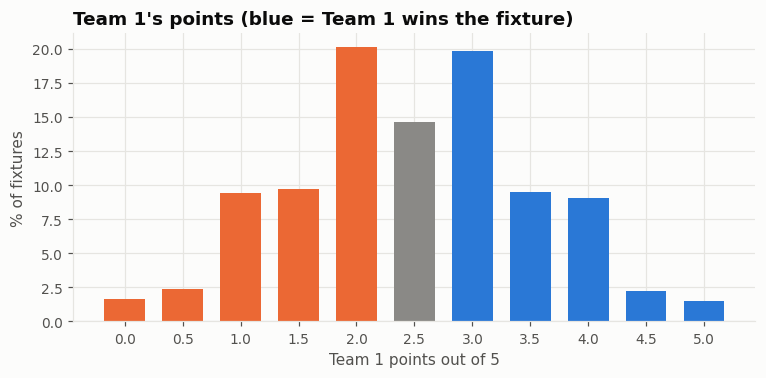

In [14]:
print(f"Fixture: Team 1 wins {res['A_win']:.1%} · draw {res['draw']:.1%} · Team 10 wins {res['B_win']:.1%} · expected points {res['exp_points_A']:.2f} – {5 - res['exp_points_A']:.2f}")
fig, ax = plt.subplots(figsize=(8, 3.4))
pdist = res["points_dist"]
cols = [PALETTE[1] if v < 2.5 else (NEUTRAL if v == 2.5 else PALETTE[0]) for v in pdist.index]
ax.bar(pdist.index.astype(str), pdist.values * 100, color=cols, width=0.7)
ax.set(title="Team 1's points (blue = Team 1 wins the fixture)", xlabel="Team 1 points out of 5", ylabel="% of fixtures")
plt.show()

Drafting by seed gives balanced teams, as the snake draft intends. An edge has to come from better player evaluation, pairing or drafting. Notebook 04 checks pairing first.

Assumptions: holes are independent, players play match play like stroke play, and we use one course. The data cannot tell us about match tactics or partnership chemistry.